In [2]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [4]:
adata = sc.read_h5ad(f"data/tom_pos_updated.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [39]:
adata.obs.timepoint_tx_days = adata.obs.timepoint_tx_days.astype(int)

In [30]:
celltype_pallete = {"HSC":"#E278C6","Meg":"#AFC7E5","Mono/DC prog":"#FFC58B",
 "Int prog":"#C8C8C8","Ery":"#8C554A","Eos":"#AD40FC",
 "Neu":"#9BDD91","Bas/MC prog":"#279F6A","Ly":"#31C6D3"}

In [31]:
adata.uns['anno_man_colors'] = [celltype_pallete[ct] for ct in adata.obs.anno_man.cat.categories]

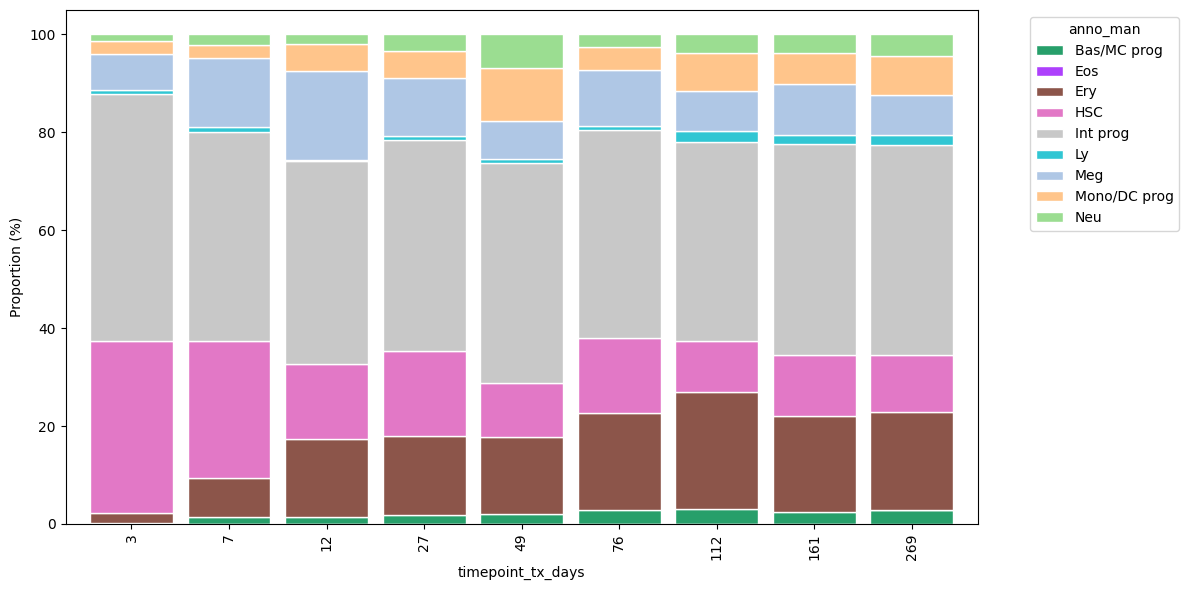

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='timepoint_tx_days', ylabel='Proportion (%)'>)

In [32]:
PINN.pl.obs_composition(adata, x_var='timepoint_tx_days', y_var='anno_man',kind='bar')

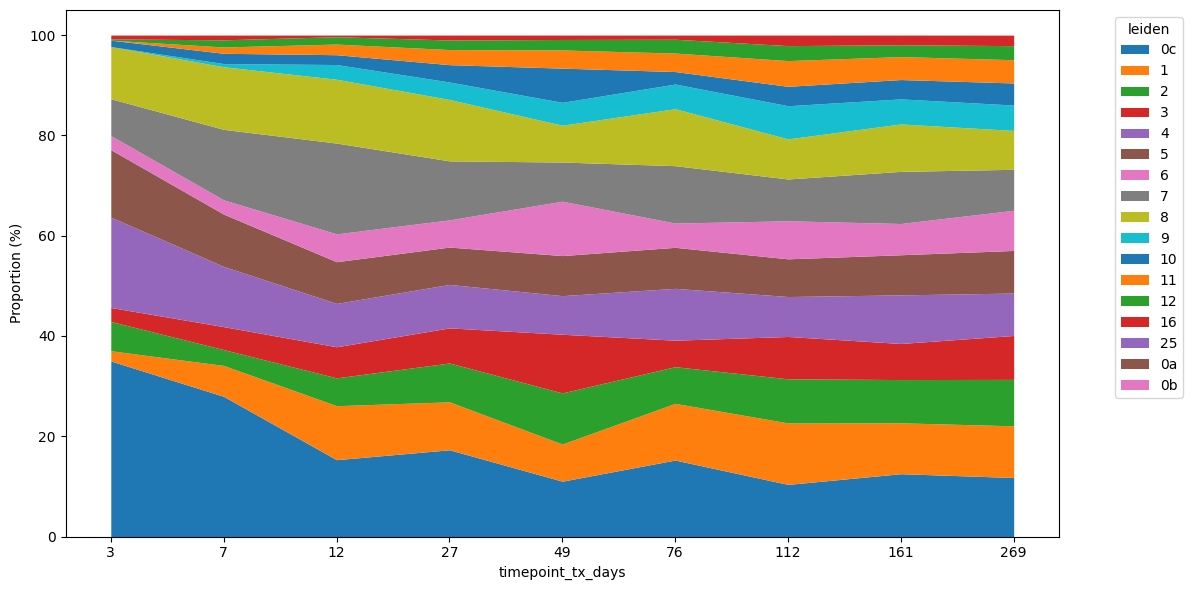

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='timepoint_tx_days', ylabel='Proportion (%)'>)

In [34]:
PINN.pl.obs_composition(adata, x_var='timepoint_tx_days', y_var='leiden',kind='area')

# density estimate

In [40]:
cellstate_key = "DM_scaled"
n_dimension = 10

Dataset = reader.TwoTimpepoint_AnnDS(
                    AnnData=adata, 
                    timepoint_idx=9, 
                    n_dimension=10,
                    cellstate_key=cellstate_key,  #'DM_EigenVector'
                    log_transform=False,
                    norm_time=False,
                    deltax_key='Delta_DM',
                    batchsize= 100)

Computing density :
`density_funs` not specified, use gaussian kde


In [48]:
Dataset.u_b.shape

torch.Size([9, 49390])

In [133]:
def sum_density_by_label(adata, obs_key, density, timepoint_key='timepoint_tx_days', timepoints=None, agg_fn='sum'):

    df = adata.obs.copy()

    if timepoints is None:
        timepoints = df[timepoint_key].unique()

    sum_u_t = []

    for i, t in enumerate(sorted(timepoints)):
        
        df[f"u"] = density[i]
        agg_u = df[['u', obs_key]].groupby(obs_key).agg(agg_fn)
        agg_u = agg_u.rename({"u":t}, axis=1)
        agg_u = agg_u / agg_u.sum()
        sum_u_t.append(agg_u)

    return pd.concat(sum_u_t, axis=1)

In [ ]:
def agg_plot(power, agg_fn):
    # cell_volumn = np.abs(Dataset.deltax.prod(axis=1, keepdims=True)
    #                 )**power

    cell_volumn = np.abs(Dataset.deltax).max(axis=1,keepdims=True)**power

    area_u = Dataset.u_b.numpy() * np.abs(cell_volumn.T)

    agg_u = sum_density_by_label(adata, 'anno_man', area_u, 
                            timepoint_key='timepoint_tx_days', agg_fn=agg_fn)
    color = adata.uns['anno_man_colors']
    agg_u.T.plot.bar(
            stacked=True,
            width=0.85,       # Bar width
            edgecolor='white', # Optional: adds separation between bars
            color=adata.uns['anno_man_colors']
            )

    plt.legend(
            title='annotation',
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
    )
    plt.title(f"power = {p}")

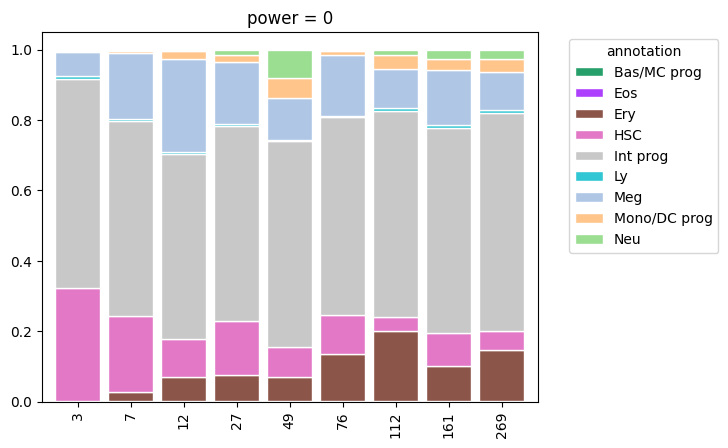

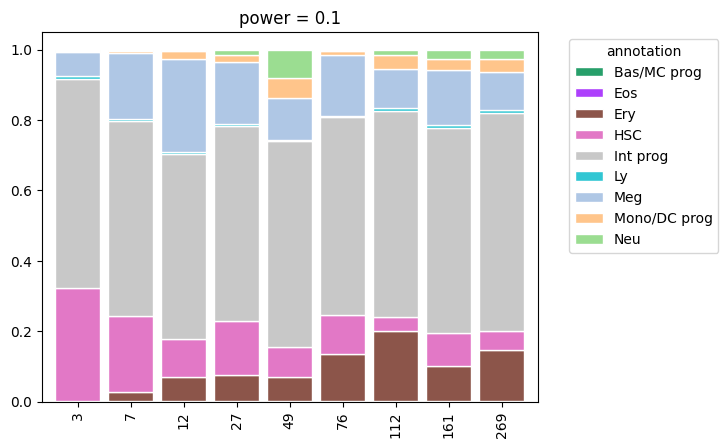

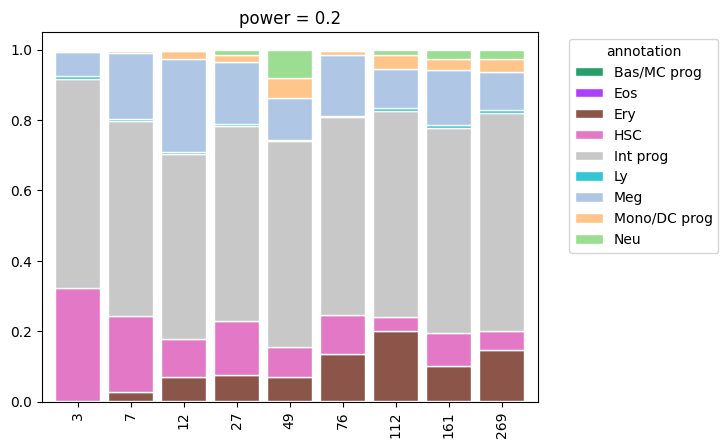

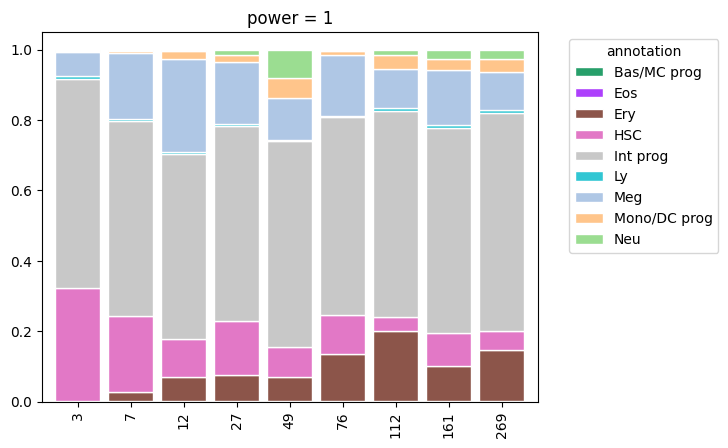

In [139]:
agg_fn = 'sum'

for p in [0, 0.1, 0.2, 1]:
    
    agg_plot(p, agg_fn)